# LLM 的“记忆力”：以 RoPE 的外推能力为切入点

谈到大语言模型的“记忆”，通常会区分三类：一是储存在模型参数中的**参数记忆**，二是由 attention 支撑的**上下文记忆**，三是以 RAG、数据库和工具调用为代表的**外部记忆**。相应地，人们也常用 LongBench、RULER、Needle-in-a-Haystack 等任务表现来评价模型的长上下文能力。

然而，这类评价更多是从人类使用工具的角度出发：模型能不能回答问题，能不能找到证据，能不能完成长文任务。它们衡量的是行为层面的有用性，而不是 Transformer 在机制层面究竟具备怎样的上下文能力。

如果从更低层的机制出发，问题就不再是 Transformer 能“记住多少字”，而是：

> 一个有限层数、有限宽度、带位置编码的注意力网络，在序列长度增长时，如何保持、路由、组合并利用上下文中的信息？

注意：此处的“路由”（routing）并不是 Transformer 原论文中的严格数学术语，而是近年来分析 Transformer 内部机制时常用的一种描述方式。它指的是：输入中某个 token 的信息如何经过 attention、残差连接、MLP 和多层表示变换，最终影响输出。换言之，路由关心的是信息在网络内部走了哪条路径。

### 上下文能力在不同层面下的细分

从这个角度看，Transformer 的上下文能力至少可以拆解为以下几个层面。

第一，**注意力可达性**。某个 token 的信息是否能够被后续 token 访问？这里的核心对象是 attention matrix。可以通过 attention entropy、attention mass、attention distance distribution 等指标观察模型是否真的在长距离位置之间建立了有效连接。

第二，**信息保持能力**。前文信息经过层层变换后，在 hidden state 中还剩下多少？这可以通过 mutual information、linear probing、representation similarity 等方法进行分析。如果远处信息虽然形式上仍在上下文窗口内，但在表示空间中已经不可恢复，那么它实际上已经被模型“遗忘”了。

第三，**位置编码的外推能力**。模型是否真的能处理超过训练长度的上下文？这涉及 RoPE、ALiBi、位置插值等位置编码机制的性质。对于 RoPE 来说，关键问题不是模型在某个长文本问答 benchmark 上得分多少，而是当相对距离超过训练窗口时，旋转相位、注意力分布和表示结构会发生怎样的变化。

第四，**信号-噪声比**。在长上下文中，目标 token 的信息是否会被大量无关 token 稀释？随着上下文长度 (n) 增大，softmax 归一化中的竞争项也随之增加。即使目标信息仍然存在，它在注意力分布中的有效权重也可能下降。

第五，**组合复杂度**。模型能否在多层 attention 中实现多步信息传递？单层 attention 更像一次全局读取，而多层 attention 才可能形成跨 token、跨层的路径组合。长上下文能力不仅取决于能不能读到远处信息，也取决于能不能把分散信息组合成新的表示。

第六，**有效上下文长度**。这不同于模型标称的 context window。真正有效的上下文长度，应该指某个远处信息源对输出分布仍然具有可测影响的最大距离。如果删除某个远处 token 后，输出分布几乎不变，那么这个 token 虽然位于窗口内，但实际上并没有被使用。

Transformer 的出色性能容易给人一种印象：只要把信息全部放进输入，attention 就会自动收集并利用这些信息，达到全量记忆的效果。但这更多是行为层面的直觉，并不等于机制层面的事实。事实上，即使在 prompt 中反复强调某条规则，模型仍可能在后续生成中违背它。不过，这也未必单纯是“记性差”的问题，不能用训练下属或提醒人类的心理学方式去理解 LLM。

其中，位置编码尤其关键。因为 attention 本身只计算 token 表示之间的相关性，而长上下文中的信息检索首先要求模型能够正确判断 token 之间的相对位置关系。如果位置关系在长度增长后发生失真，那么远处 token 虽然仍然在窗口内，却可能无法以训练阶段熟悉的方式参与 attention 计算。也就是说，所谓“记得住”，首先要求模型在更长序列上仍能维持稳定的位置几何结构。

因此，本文将**以 RoPE 为切入点，考察在固定长度 token block 上训练语言模型时，当模型遇到超过训练窗口的上下文，会发生什么**。重点包括：RoPE 数值外推行为的可视化、长距离位置关系下的 attention 变化，以及上下文 token 信息保持力度的分析。借此，我们尝试从机制层面重新理解大语言模型所谓的“记忆力”。

概括来说，长上下文能力可以分为三个层次：

**行为层指标**：LongBench、RULER、Needle-in-a-Haystack。

**机制层指标**：attention entropy、attention distance、representation retention、causal ablation、information flow。

**数理层问题**：复杂度、容量、位置外推、softmax 稀释、层数与组合路径。

本文关注的不是模型在长上下文任务上“好不好用”，而是 Transformer 在长度外推条件下，究竟如何保存、传递和利用信息。


## RoPE 的原理与实现

目前常见的位置编码方法包括绝对位置编码、相对位置编码、ALiBi 以及目前大多数大语言模型采用的 Rotary Position Embedding（RoPE）。

相比传统的位置编码，RoPE 最大的特点在于：它并不直接编码绝对位置，而是通过旋转变换，使 Attention 的计算天然依赖于 token 之间的相对距离。这一性质使得 RoPE 在长上下文任务中表现出更好的泛化能力，也使它成为研究 Transformer 上下文能力和长度外推问题的重要切入点。

因此，在讨论大语言模型的"记忆力"时，我们首先需要理解 RoPE 是如何工作的，以及它为什么既能支持长上下文，又会在超过训练长度后逐渐失效。

### RoPE 的数学原理

RoPE 的核心思想可以概括为一句话：

> **通过对 Query 和 Key 施加与位置相关的旋转变换，使 Attention 的内积结果仅依赖于 token 之间的相对位置，而非绝对位置。**

与传统的位置编码将位置向量直接加到 embedding 上不同，RoPE 将位置编码融入到了 Attention 的计算过程。


#### RoPE 的操作对象

设输入序列长度为 $L$，模型隐层维度为 $d_{\mathrm{model}}$。经过 embedding 和前面若干层 Transformer 之后，当前层的输入表示为

$$
X \in \mathbb{R}^{L \times d_{\mathrm{model}}}.
$$

对于某一个 attention head，Query 和 Key 由线性投影得到：

$$
Q = XW_Q,
\qquad
K = XW_K.
$$

其中

$$
W_Q,W_K \in \mathbb{R}^{d_{\mathrm{model}} \times d},
$$

$d$ 是每个 attention head 的维度。因此

$$
Q,K \in \mathbb{R}^{L \times d}.
$$

这时，$Q$ 的**第 $m$ 行**表示第 $m$ 个 token 对应的 Query 向量：

$$
q_m = Q[m,:] \in \mathbb{R}^{d}.
$$

$K$ 的**第 $n$ 行**表示第 $n$ 个 token 对应的 Key 向量：

$$
k_n = K[n,:] \in \mathbb{R}^{d}.
$$

也就是说，$q_m$ 不是一个独立的 Query 矩阵，而是整个 Query 矩阵 $Q$ 中对应第 $m$ 个位置的一行向量。类似地，$k_n$ 是 Key 矩阵 $K$ 中对应第 $n$ 个位置的一行向量。这里的 $d$ 指的是每个 attention head 内部的特征维度，我们默认每个 attention head 的维度 $d$ 为偶数。若 $d$ 为奇数，则只能对其中偶数个维度施加 RoPE，剩余维度保持不变，或者在模型设计时直接令 $d$ 为偶数。


#### 两两拆分

接下来，RoPE 把**同一个 Query 或 Key 向量内部的特征维度按相邻两维划分为若干二维子空间**（并不是把不同 token 两两分组，也不是把 Query 和 Key 两两分组）。

例如，对于 Query 向量

$$
q_m=(q_{m,0},q_{m,1},q_{m,2},q_{m,3},\cdots,q_{m,d-2},q_{m,d-1}),
$$

RoPE 将其划分为

$$
(q_{m,0},q_{m,1}),\quad
(q_{m,2},q_{m,3}),\quad
\cdots,\quad
(q_{m,d-2},q_{m,d-1}).
$$

对于 Key 向量

$$
k_n=(k_{n,0},k_{n,1},k_{n,2},k_{n,3},\cdots,k_{n,d-2},k_{n,d-1}),
$$

也同样划分为

$$
(k_{n,0},k_{n,1}),\quad
(k_{n,2},k_{n,3}),\quad
\cdots,\quad
(k_{n,d-2},k_{n,d-1}).
$$

对于第 $i$ 个二维子空间，定义对于 token 位置的角频率

$$
\theta_i = 10000^{-2i/d},
\qquad i=0,1,\cdots,\frac d2-1.
$$

在位置 $m$ 上，第 $i$ 个二维子空间对应的旋转矩阵为

$$
R_i(m)=
\begin{bmatrix}
\cos(m\theta_i) & -\sin(m\theta_i)\\
\sin(m\theta_i) & \cos(m\theta_i)
\end{bmatrix}.
$$

因此，Query 向量中第 $i$ 个二维子空间会被旋转为

$$
\begin{bmatrix}
\tilde q_{m,2i}\
\tilde q_{m,2i+1}
\end{bmatrix}
=
R_i(m)
\begin{bmatrix}
q_{m,2i}\
q_{m,2i+1}
\end{bmatrix}.
$$

同理，Key 向量中第 $i$ 个二维子空间会被旋转为

$$
\begin{bmatrix}
\tilde k_{n,2i}\
\tilde k_{n,2i+1}
\end{bmatrix}
=
R_i(n)
\begin{bmatrix}
k_{n,2i}\
k_{n,2i+1}
\end{bmatrix}.
$$

把所有二维子空间合在一起，就可以得到一个块对角矩阵：

$$
\mathcal R(m)
=
\operatorname{diag}
\left(
R_0(m),
R_1(m),
\cdots,
R_{d/2-1}(m)
\right).
$$

于是，RoPE 后的 Query 和 Key 可以写成

$$
\tilde q_m = \mathcal R(m)q_m,
\qquad
\tilde k_n = \mathcal R(n)k_n.
$$


#### RoPE 的应用

在 $q_m$ 与 $k_n$ 经 RoPE 处理后，Attention score 不再使用原始内积

$$
q_m^\top k_n,
$$

而是使用旋转后的内积

$$
\tilde q_m^\top \tilde k_n.
$$

展开可得

$$
\begin{aligned}
\tilde q_m^\top \tilde k_n
&=
\left(\mathcal R(m)q_m\right)^\top
\left(\mathcal R(n)k_n\right)\
&=
q_m^\top \mathcal R(m)^\top \mathcal R(n) k_n.
\end{aligned}
$$

由于二维旋转矩阵满足

$$
R_i(m)^\top R_i(n)=R_i(n-m),
$$

所以整个块对角旋转矩阵也满足

$$
\mathcal R(m)^\top \mathcal R(n)
=
\mathcal R(n-m).
$$

因此

$$
\tilde q_m^\top \tilde k_n
=
q_m^\top \mathcal R(n-m) k_n.
$$

对应地，加入 RoPE 之后，attention score 可以写成：

$$
\tilde s_{mn}
=
\frac{\tilde q_m^\top \tilde k_n}{\sqrt{d}}.
$$

将上面的结果代入，可得：

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt{d}}.
$$

其中，$\tilde s_{mn}$ 表示位置 $m$ 的 Query 对位置 $n$ 的 Key 的注意力打分，$d$ 是每个 attention head 的维度。最后要注意的是，RoPE 通常只作用在 Query 和 Key 上，而不作用在 Value 上。因此，RoPE 改变的是“看哪里”的权重计算，而不是直接旋转被取出的内容 $v_n$。


#### 重点来了~

从上面的推导中我们可以发现 RoPE 最关键的性质：Query 和 Key 在进入 attention score 之前，确实分别使用了自己的绝对位置 $m$ 和 $n$。位置 $m$ 的 Query 会被旋转 $m\theta_i$，位置 $n$ 的 Key 会被旋转 $n\theta_i$。

但是二者做内积时，真正起作用的不是这两个绝对角度本身，而是它们之间的角度差：

$$
n\theta_i - m\theta_i = (n-m)\theta_i.
$$

也就是说，对于第 $i$ 个二维子空间，attention score 看到的不是“Query 在第 $m$ 个位置，Key 在第 $n$ 个位置”，而是：

$$
\text{Key 相对于 Query 偏移了 } n-m \text{ 个 token。}
$$

例如，如果当前位置是 $m=100$，被关注的 token 在 $n=90$，那么 RoPE 在内积中留下来的位置信息就是：

$$
n-m = -10.
$$

如果当前位置换成 $m=1000$，被关注的 token 在 $n=990$，那么：

$$
n-m = -10.
$$

二者的绝对位置完全不同，一个发生在 100 附近，一个发生在 1000 附近；但从 RoPE 的 attention score 看，它们具有相同的相对距离结构：Key 都在 Query 前面 10 个 token 的位置。

因此，RoPE 并不是直接告诉模型“这是第 100 个 token”或“这是第 1000 个 token”。它做的是：先用绝对位置决定 Query 和 Key 各自应该旋转多少角度，然后在二者内积时，让这两个绝对旋转角度相互抵消，只留下相对位移带来的相位差。

所以更准确地说：

> RoPE 使用绝对位置来旋转 Query 和 Key，attention score 最终感受到的是 Query 和 Key 之间的相对位置差。

从这个角度看，RoPE 的本质是：

> 在 Query 和 Key 的特征空间中引入与位置相关的旋转，使 token 之间的相对位置 自然融入 Attention score 里。

这也是 RoPE 比普通绝对位置编码更适合长上下文的原因之一：模型不必为每一个绝对位置单独学习一个位置表示，而是可以学习“相隔 1 个 token”“相隔 10 个 token”“相隔 100 个 token”这类相对距离模式。

需要注意的是，RoPE 本身并不会显式输出一个名为“相对距离”的变量。它只是通过旋转相位差，把相对位置信息编码进 Query 和 Key 的内积结构中。Transformer 会在训练过程中自己学习如何利用这种结构：某些 attention head 可能学会关注临近 token，某些 head 可能学会关注句首、段落边界或更远处的依赖关系。也就是说，相对位置信息并不是被人工规则直接读出，而是作为 attention score 中可被利用的几何结构，供模型在语言建模目标下自行解析和使用。

因此，更准确地说，RoPE 提供的是一种“相对位置可解析的表示空间”：它把相对距离编码进内积关系中，而 Transformer 通过训练学会从这种内积变化中提取有用的位置模式。


#### RoPE 的优势

这种设计带来了两个重要优势。

首先，由于位置关系体现在相对距离上，而不是固定的位置编号，因此模型在一定程度上具有比绝对位置编码更好的长度泛化能力。

其次，不同维度对应不同频率的旋转角速度。低频维度变化缓慢，可以稳定表示远距离的位置关系；高频维度变化较快，能够提供精细的局部位置信息。多种频率共同构成了一种类似傅里叶基底（Fourier basis）的表示，使模型能够同时感知局部和全局的位置关系。

然而，这种表示也埋下了长度外推的隐患。由于旋转角度会随着位置线性增长，当上下文长度远远超过训练窗口时，高频分量首先发生剧烈振荡，而低频分量也逐渐累积误差。虽然 RoPE 在数学上可以对任意长度计算旋转矩阵，但模型真正学习到的却只是训练窗口内的相位分布。因此，当推理长度不断增加时，Attention 中的位置关系会逐渐偏离训练阶段所学习到的分布，这正是长上下文性能下降的重要原因，也是后文将重点分析的内容。


### 为什么不直接编码相对位置？

既然 RoPE 最终也是为了让 attention score 感知相对距离 $n-m$，一个自然的问题是：为什么不直接把相对位置编码进去？

事实上，直接编码相对位置当然是可以的。很多位置编码方法正是这样做的。例如，可以在 attention score 中直接加入一个相对位置偏置：

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt{d}}
+
b_{n-m}.
$$

其中，$s_{mn}$ 表示位置 $m$ 的 Query 对位置 $n$ 的 Key 的注意力打分，$b_{n-m}$ 是一个只由相对距离 $n-m$ 决定的位置偏置。

这种方法非常直观。它相当于直接告诉模型：

> 当前位置 $m$ 和被关注位置 $n$ 之间相差 $n-m$ 个 token。

例如，如果 $n-m=-10$，就使用距离为 $-10$ 的位置偏置 $b_{-10}$；如果 $n-m=-100$，就使用距离为 $-100$ 的位置偏置 $b_{-100}$。

但是，这类直接相对位置编码通常有几个问题。

#### 第一，它往往是**内容无关的**

在下面的公式中：

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt{d}}
+
b_{n-m},
$$

相对位置项 $b_{n-m}$ 只和距离有关，而不和 token 的内容有关。也就是说，不管当前位置是名词、动词、括号还是变量名，只要相对距离相同，加入的偏置就是同一个。

这当然有用，但它更像是在 attention score 上加入一个固定的位置先验。例如，模型可以学到“附近的 token 通常更重要”，或者“某些距离上的 token 更值得关注”。但是，这种相对位置项并没有改变 Query 和 Key 之间的内容匹配方式。

RoPE 的做法不同。加入 RoPE 后，attention score 可以写成：

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt{d}}.
$$

这里的相对距离 $n-m$ 不是作为一个额外的 bias 加到 attention score 上，而是直接参与了 Query 和 Key 的内积计算。

如果使用相对位置 bias，attention score 是：

$$
s_{mn}
=
\frac{q_m^\top k_n}{\sqrt d}
+
b_{n-m}.
$$

这表示：先计算 $q_m$ 和 $k_n$ 的内容相似度，再根据距离 $n-m$ 额外加上一个分数。这个位置项 $b_{n-m}$ 和 Query、Key 的具体内容无关。只要相对距离相同，加的分数就是一样的。

也就是说，bias 的作用更像是：

> 不管这两个 token 是什么内容，只要它们相隔这个距离，就统一加一点分或扣一点分。

RoPE 的方式不同。RoPE 后的 attention score 是：

$$
\tilde s_{mn}
=
\frac{
q_m^\top \mathcal R(n-m) k_n
}{\sqrt d}.
$$

这里的 $\mathcal R(n-m)$ 会先根据相对距离旋转 Key 的表示，然后再和 Query 做内积。也就是说，距离 $n-m$ 改变的不是一个额外分数，而是改变了 $q_m$ 和 $k_n$ 在向量空间中的对齐方式。

可以只看一个二维子空间。设

$$
q=(a,b),
\qquad
k=(c,d),
$$

相对距离对应的旋转角为

$$
\phi=(n-m)\theta_i.
$$

那么 RoPE 中这一组二维向量的内积为：

$$
q^\top R(\phi)k
=
(ac+bd)\cos\phi
+
(bc-ad)\sin\phi.
$$

可以看到，位置关系并不是简单地贡献一个固定偏置 $b_{n-m}$。相对距离 $\phi$ 会通过 $\cos\phi$ 和 $\sin\phi$ 改变不同内容分量的组合方式。所以，RoPE 并不是让位置本身变得“有内容”，而是让位置关系以一种乘法形式进入内容匹配过程。它把“两个 token 的内容是否匹配”和“它们相隔多远”放在同一个内积结构里共同计算。

换句话说，同样是距离 $-10$，不同的 Query 和 Key 会得到不同的影响；相同的相对距离 $n-m$，对不同的 $q_m$ 和 $k_n$ 可能产生不同影响；相同的一对 $q_m$ 和 $k_n$，在不同相对距离下也会得到不同的内积结果。

这种设计的潜在优势在于，**模型可以在训练中学习如何把不同类型的信息放到不同的频率子空间中**。某些 head 可以利用高频维度处理局部依赖，某些 head 可以利用低频维度处理较长距离关系。RoPE 提供的是一种可被模型利用的位置几何结构，而不是直接规定某个距离一定应该加多少分。

#### 第二，直接学习相对位置表会把长度外推问题暴露得更加明显。

假设我们为每个相对距离都学习一个位置偏置：

$$
b_{-1}, b_{-2}, b_{-3}, \cdots, b_{-L}.
$$

如果训练窗口长度为 $L$，那么模型只会学习到这个范围内的距离参数。一旦推理时上下文长度超过训练窗口，就会出现训练阶段没有对应参数的距离，例如：

$$
b_{-10000},\quad b_{-20000},\quad b_{-30000}.
$$

这时必须额外规定这些未见距离应该如何处理，例如截断、插值、分桶，或者让远距离共享同一个偏置。也就是说，直接学习相对位置表本身并没有自然定义训练范围之外的位置关系。

RoPE 的不同之处在于，它不是为每一个相对距离单独存一个参数，而是用连续函数生成位置关系：

$$
\cos((n-m)\theta_i),
\qquad
\sin((n-m)\theta_i).
$$

因此，从表示形式上说，任意相对距离 $n-m$ 都可以被代入计算。即使 $n-m$ 超过训练时见过的最大距离，RoPE 仍然能给出一个确定的旋转相位。

但这并不意味着 RoPE 真正解决了长度外推问题。它只保证了“未见距离在数学上可计算”，并不保证模型“学会了如何使用这些未见距离”。

这两者是不同层次的问题：

- **表示层面**：超过训练长度的位置关系是否有定义；
- **学习层面**：模型是否在训练中学会了如何利用这些位置关系。

RoPE 在表示层面比纯查表式相对位置编码更自然，因为它不需要为每一个距离单独学习参数，也不会在超过训练长度后立刻出现“没有这个位置参数”的问题。但是在学习层面，RoPE 仍然面对同样的分布外外推问题：模型训练时只见过有限范围内的相位组合，推理时遇到更长距离下的相位模式，仍然可能无法稳定解释。

因此，RoPE 的优势不应该被理解为“它能让模型自动学会任意长距离依赖”。更准确地说，RoPE 提供了一种连续、参数共享的位置几何结构，使得长度外推在形式上成为可能；但这种结构是否真的能被模型利用，仍然取决于训练长度、频率设计、模型规模和注意力头是否学到了可外推的位置规律。

#### 第三，RoPE 对 decoder-only language model 的推理实现比较友好。

在自回归生成中，模型会缓存过去 token 的 Key 和 Value，也就是 KV cache。使用 RoPE 时，过去位置 $n$ 的 Key 可以在生成时就被旋转好：

$$
\tilde k_n = \mathcal R(n)k_n.
$$

当模型生成到新位置 $m$ 时，只需要计算当前 Query 的旋转：

$$
\tilde q_m = \mathcal R(m)q_m.
$$

然后直接计算：

$$
\tilde q_m^\top \tilde k_n.
$$

这样，RoPE 和普通 attention 的矩阵乘法形式非常兼容，不需要在每一步显式构造复杂的相对位置表。

---

## 补充实验1：绝对位置编码 vs RoPE 的长度外推

前面的讨论主要说明了 RoPE 为什么在表示层面更适合长度外推。这里补充一个最低限度实验，用来直观看到两种位置编码在**训练长度之外**的行为差异。

这个实验很简单：

1. 训练时只让模型只看见一种较短长度，例如 $L=64$；
2. 测试时把序列长度扩展到 $80,96,128,160,192$；
3. 任务不是语言建模，而是一个纯粹的相对位置检索任务：最后一个 token 是查询 token，模型需要输出距离它固定步数之前的那个 token；
4. 对比两种位置编码：
   - **Direct / absolute position embedding**：把可学习的位置向量直接加到 token embedding 上；
   - **RoPE**：不把位置向量直接加到输入上，而是在 attention 的 Query/Key 上施加旋转。

任务形式如下。设查询 token 位于最后一个位置 $t=L-1$，固定 offset 为 $k$，模型需要输出：

$$
y = x_{L-1-k}.
$$

如果模型学到的是“某个绝对位置上的 token”，它在测试长度变长后会很容易失效。因为最后一个 query token 的绝对位置从训练阶段的 $63$ 变成了 $79,95,127,159,191$ 等未训练位置。  
如果模型学到的是“从当前位置向前数 $k$ 个位置”，那么这种规则就更接近相对位置结构，RoPE 理论上更容易外推。

注意：这个实验不是为了证明 RoPE 可以解决所有长上下文问题。它只说明一件事：在一个依赖相对距离的 toy task 中，RoPE 的位置表示比直接绝对位置 embedding 更容易在长度变长后保持规则。

In [1]:
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# 小模型实验在 CPU 上有时会被多线程调度拖慢；单线程通常更稳定。
if not torch.cuda.is_available():
    torch.set_num_threads(1)

# -----------------------------
# Basic configuration
# -----------------------------

SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

VALUE_VOCAB_SIZE = 32       # 普通 token 的取值范围：0 ~ 31
QUERY_TOKEN_ID = VALUE_VOCAB_SIZE
TOTAL_VOCAB_SIZE = VALUE_VOCAB_SIZE + 1

OFFSET = 16                 # 任务：输出 query token 前面第 OFFSET 个 token
TRAIN_LEN = 64
TEST_LENGTHS = [64, 80, 96, 128, 160, 192]
MAX_TEST_LEN = max(TEST_LENGTHS)

D_MODEL = 48
N_HEAD = 4
DROPOUT = 0.0

BATCH_SIZE = 64
TRAIN_STEPS = 600           # 如果只是检查代码能否跑通，可以先改成 100；想要曲线更稳定可改成 1000
LR = 1e-3
EVAL_BATCHES = 10

print("device:", DEVICE)

device: cuda


In [2]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_batch(
    batch_size: int,
    seq_len: int | None = None,
    train_len: int = TRAIN_LEN,
    offset: int = OFFSET,
    device: str = DEVICE,
):
    """
    构造一个相对位置检索任务。

    输入:
        x: [B, L]
           前 L-1 个位置是随机 token，最后一个位置是 QUERY_TOKEN_ID。
    标签:
        y = 原始序列中距离 query token 前 offset 个位置的 token。

    也就是说，query 在最后一位，模型必须学会：
        "从当前位置向前数 offset 个位置，读出那个 token 的值。"
    """
    if seq_len is None:
        seq_len = train_len

    assert seq_len > offset + 1, "序列长度必须大于 OFFSET。"

    x = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len),
        device=device,
    )

    y = x[:, -1 - offset].clone()
    x[:, -1] = QUERY_TOKEN_ID
    return x, y

In [3]:
def apply_rope(x: torch.Tensor, base: float = 10000.0):
    """
    对 q 或 k 施加 RoPE。

    x shape:
        [B, n_head, T, head_dim]

    RoPE 在每个二维子空间中执行旋转：
        (x_0, x_1), (x_2, x_3), ...
    """
    B, H, T, D = x.shape
    assert D % 2 == 0, "RoPE requires an even head_dim."

    device = x.device
    dtype = x.dtype

    inv_freq = 1.0 / (base ** (torch.arange(0, D, 2, device=device, dtype=dtype) / D))
    pos = torch.arange(T, device=device, dtype=dtype)
    freqs = torch.einsum("t,d->td", pos, inv_freq)

    cos = freqs.cos()[None, None, :, :]
    sin = freqs.sin()[None, None, :, :]

    x_even = x[..., 0::2]
    x_odd = x[..., 1::2]

    out = torch.empty_like(x)
    out[..., 0::2] = x_even * cos - x_odd * sin
    out[..., 1::2] = x_even * sin + x_odd * cos
    return out


class TinyLastQueryRetriever(nn.Module):
    """
    一个极简模型：只让最后一个 query token 对整段序列做一次 attention。

    这样做的好处是：
    1. 训练很快；
    2. 实验更纯粹，几乎只考察模型能否学会相对位置检索；
    3. 仍然保留 Transformer 中最核心的 Q/K/V attention 结构。
    """
    def __init__(
        self,
        pos_type: str,
        vocab_size: int = TOTAL_VOCAB_SIZE,
        value_vocab_size: int = VALUE_VOCAB_SIZE,
        d_model: int = D_MODEL,
        n_head: int = N_HEAD,
        max_len: int = MAX_TEST_LEN,
        dropout: float = DROPOUT,
    ):
        super().__init__()
        assert pos_type in {"absolute", "rope"}
        assert d_model % n_head == 0

        self.pos_type = pos_type
        self.max_len = max_len
        self.d_model = d_model
        self.n_head = n_head
        self.head_dim = d_model // n_head

        self.token_emb = nn.Embedding(vocab_size, d_model)

        # Direct absolute position embedding.
        # 这里故意把 max_len 设置到测试长度。
        # 这样测试时不会越界，但训练只更新 0 ~ TRAIN_MAX_LEN-1 的位置。
        # 超过训练长度的位置 embedding 仍然基本是未训练状态。
        if pos_type == "absolute":
            self.pos_emb = nn.Embedding(max_len, d_model)
        else:
            self.pos_emb = None

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, value_vocab_size)

    def forward(self, idx: torch.Tensor, return_attn: bool = False):
        B, T = idx.shape

        x = self.token_emb(idx)

        if self.pos_type == "absolute":
            if T > self.max_len:
                raise ValueError(f"sequence length {T} > max_len {self.max_len}")
            pos = torch.arange(T, device=idx.device)
            x = x + self.pos_emb(pos)[None, :, :]

        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if self.pos_type == "rope":
            q = apply_rope(q)
            k = apply_rope(k)

        # 只取最后一个位置作为 query。
        q_last = q[:, :, -1:, :]              # [B, H, 1, D]
        scores = q_last @ k.transpose(-2, -1)
        scores = scores / math.sqrt(self.head_dim)

        att = F.softmax(scores, dim=-1)       # [B, H, 1, T]
        att = self.dropout(att)

        ctx = att @ v                         # [B, H, 1, D]
        ctx = ctx.transpose(1, 2).contiguous().view(B, 1, self.d_model)
        ctx = ctx[:, 0, :]

        logits = self.head(self.ln(self.out_proj(ctx)))

        if return_attn:
            # 平均所有 attention heads，便于可视化。
            return logits, att.mean(dim=1).squeeze(1)

        return logits

In [4]:
def train_model(pos_type: str, train_steps: int = TRAIN_STEPS):
    set_seed(SEED)

    model = TinyLastQueryRetriever(pos_type=pos_type).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    history = []
    model.train()

    for step in range(1, train_steps + 1):
        x, y = make_batch(BATCH_SIZE, seq_len=TRAIN_LEN)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 100 == 0:
            with torch.no_grad():
                acc = (logits.argmax(dim=-1) == y).float().mean().item()
            history.append({
                "pos_type": pos_type,
                "step": step,
                "loss": loss.item(),
                "train_batch_acc": acc,
            })
            print(f"{pos_type:>8s} | step {step:4d} | loss {loss.item():.4f} | train acc {acc:.3f}")

    return model, pd.DataFrame(history)


@torch.no_grad()
def evaluate_model(model: nn.Module, lengths: list[int], eval_batches: int = EVAL_BATCHES):
    model.eval()

    rows = []

    for L in lengths:
        correct = 0
        total = 0

        for _ in range(eval_batches):
            x, y = make_batch(BATCH_SIZE, seq_len=L)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            correct += (pred == y).sum().item()
            total += y.numel()

        rows.append({
            "pos_type": model.pos_type,
            "seq_len": L,
            "is_extrapolation": L > TRAIN_LEN,
            "accuracy": correct / total,
        })

    return pd.DataFrame(rows)

In [5]:
models = {}
histories = []
results = []

for pos_type in ["absolute", "rope"]:
    print("=" * 80)
    print("training:", pos_type)
    model, hist = train_model(pos_type)
    models[pos_type] = model
    histories.append(hist)

    result = evaluate_model(model, TEST_LENGTHS)
    results.append(result)

history_df = pd.concat(histories, ignore_index=True)
result_df = pd.concat(results, ignore_index=True)

display(result_df)

training: absolute
absolute | step    1 | loss 3.6474 | train acc 0.016
absolute | step  100 | loss 0.7277 | train acc 1.000
absolute | step  200 | loss 0.0941 | train acc 1.000
absolute | step  300 | loss 0.0386 | train acc 1.000
absolute | step  400 | loss 0.0219 | train acc 1.000
absolute | step  500 | loss 0.0142 | train acc 1.000
absolute | step  600 | loss 0.0097 | train acc 1.000
training: rope
    rope | step    1 | loss 3.5489 | train acc 0.062
    rope | step  100 | loss 3.2091 | train acc 0.219
    rope | step  200 | loss 0.9039 | train acc 0.812
    rope | step  300 | loss 0.3238 | train acc 0.891
    rope | step  400 | loss 0.2379 | train acc 0.922
    rope | step  500 | loss 0.0883 | train acc 0.938
    rope | step  600 | loss 0.0928 | train acc 0.969


,pos_type,seq_len,is_extrapolation,accuracy
0,absolute,64,False,1.000000
1,absolute,80,True,0.043750
2,absolute,96,True,0.028125
3,absolute,128,True,0.035937
4,absolute,160,True,0.020313
5,absolute,192,True,0.026562
6,rope,64,False,0.929688
7,rope,80,True,0.889062
8,rope,96,True,0.860938
9,rope,128,True,0.093750


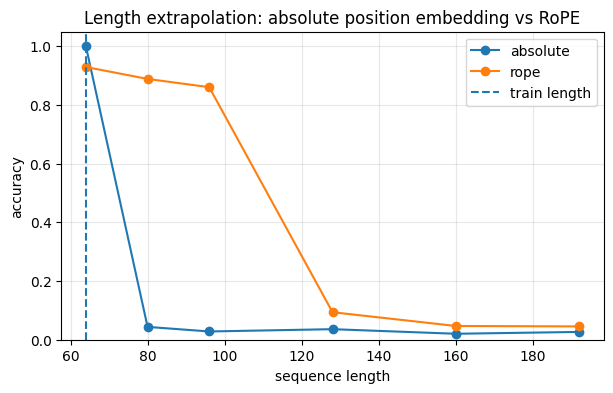

In [6]:
plt.figure(figsize=(7, 4))

for pos_type, group in result_df.groupby("pos_type"):
    group = group.sort_values("seq_len")
    plt.plot(group["seq_len"], group["accuracy"], marker="o", label=pos_type)

plt.axvline(TRAIN_LEN, linestyle="--", label="train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Length extrapolation: absolute position embedding vs RoPE")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

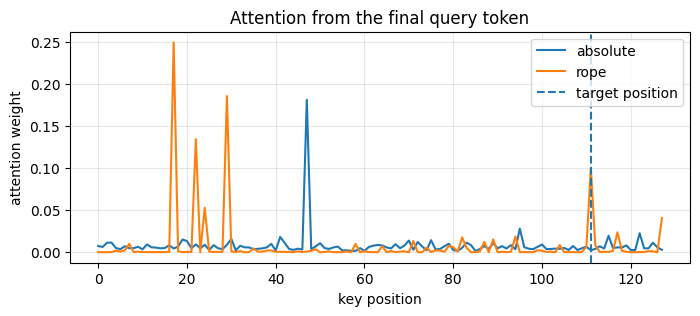

target value: 6
prediction: {'absolute': 8, 'rope': 16}


In [7]:
# Optional: visualize where the trained models attend on a long sequence.
# The correct target position is marked by the vertical dashed line.

L = 128
x, y = make_batch(batch_size=1, seq_len=L)

target_pos = L - 1 - OFFSET

plt.figure(figsize=(8, 3))

for pos_type, model in models.items():
    model.eval()
    with torch.no_grad():
        logits, att = model(x, return_attn=True)
    plt.plot(att[0].detach().cpu().numpy(), label=pos_type)

plt.axvline(target_pos, linestyle="--", label="target position")
plt.xlabel("key position")
plt.ylabel("attention weight")
plt.title("Attention from the final query token")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("target value:", int(y.item()))
print("prediction:", {k: int(m(x).argmax(dim=-1).item()) for k, m in models.items()})

### 如何解读这个实验

一般情况下，你会看到三类现象。

第一，在训练长度范围内，例如 $L = 64$，两种模型都可能学得不错。这说明任务本身并不难，模型容量也足够。

第二，超过训练长度后，direct absolute position embedding 往往会明显下降。原因不是 attention 公式不能计算，而是超过训练长度后，query token 所在位置的 position embedding 在训练中没有被更新。于是 query token 位于 $79,95,127,159,191$ 等位置时，输入分布已经和训练阶段不同。

第三，RoPE 通常会下降得更慢。因为 RoPE 没有为每个绝对位置单独学习一个位置向量，而是在 Query 和 Key 上使用连续的旋转相位。也就是说，对于新的序列长度，位置关系仍然有明确的计算形式：

$$
q_m^\top R_{n-m} k_n.
$$

因此，RoPE 更容易表达“距离当前 token 前 $k$ 个位置”这种相对规则。

但是，这里也要强调：RoPE 的优势不是“无限长都能用”。当测试长度继续增大时，它仍然可能下降。原因包括：

1. 训练时没有见过那么长的 attention 候选集合；
2. softmax 的竞争项变多，噪声 key 更容易抢走注意力；
3. RoPE 的高频维度可能出现相位缠绕；
4. 模型参数只在短上下文分布上被优化过。

所以更准确的结论是：

> RoPE 让训练长度之外的位置关系在数学上仍然可计算，并且比直接绝对位置 embedding 更容易复用相对位置规则；但它并不保证模型自动学会任意长度的上下文检索。

---

## 补充实验 2：直接相对位置编码的优势与边界

补充实验 1 比较了绝对位置编码和 RoPE，说明绝对位置编码在长度外推时容易遇到未训练绝对位置的问题。

但是这个比较还不够完整。因为别人可以合理地质疑：如果不用绝对位置编码，而是使用直接相对位置编码，那么模型同样可以表示“query 前面第 $k$ 个 token”这种关系。

因此，补充实验 2 分成两个部分。

第一部分是 **seen relative distance control**。我们仍然使用固定 offset 检索任务：

$$
y = x_{T-1-k}
$$

其中 $k$ 在训练和测试中保持不变。这个实验用来说明：如果目标相对距离 $k$ 在训练中已经出现过，那么 direct learned relative position encoding 也可以在更长序列上工作。也就是说，RoPE 在这个任务上的优势并不是因为“只有 RoPE 会相对位置”，而是因为绝对位置编码本身遇到了未训练绝对位置的问题。

第二部分是 **unseen relative distance stress test**。我们让模型在训练时只接触不超过训练长度的相对距离，然后在测试时要求它处理更长序列中才会出现的相对距离。对于 direct learned relative position encoding 来说，每一个相对距离都有一个独立参数：

$$
r_0, r_1, r_2, \cdots
$$

训练中没有出现过的距离虽然可以预先创建对应表项，但这些表项没有被有效更新。因此，它们只是“存在”，而不是“学过”。

RoPE 的区别在于，它不是为每个相对距离单独学习一个参数，而是通过连续的旋转结构计算相对位置关系。因此，RoPE 至少在表示形式上可以自然延伸到训练长度之外。不过，这并不保证 RoPE 一定能解决所有长距离任务，它只说明 RoPE 没有 direct relative table 那种“训练外距离表项未学习”的硬边界问题。

In [9]:
# ============================================================
# Supplementary Experiment 2
# Direct relative encoding: seen-distance control and unseen-distance stress test
# ============================================================

try:
    OFFSET
except NameError:
    OFFSET = 8


def make_fixed_offset_batch(batch_size, seq_len, offset=OFFSET):
    """
    Fixed-offset retrieval.

    Input:
        [v_0, v_1, ..., v_{T-2}, QUERY]

    Target:
        token at position T - 1 - offset

    The required relative distance is always `offset`.
    """
    assert seq_len >= offset + 2

    values = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len - 1),
        device=DEVICE,
    )

    query = torch.full(
        (batch_size, 1),
        QUERY_TOKEN_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    x = torch.cat([values, query], dim=1)
    target_pos = seq_len - 1 - offset
    y = x[:, target_pos]

    return x, y


def make_first_token_batch_exp2(batch_size, seq_len):
    """
    First-token retrieval.

    Input:
        [v_0, v_1, ..., v_{T-2}, QUERY]

    Target:
        v_0

    The required relative distance is T - 1.
    Therefore, when T becomes larger than the training length,
    the task requires unseen relative distances.
    """
    assert seq_len >= 4

    values = torch.randint(
        low=0,
        high=VALUE_VOCAB_SIZE,
        size=(batch_size, seq_len - 1),
        device=DEVICE,
    )

    query = torch.full(
        (batch_size, 1),
        QUERY_TOKEN_ID,
        dtype=torch.long,
        device=DEVICE,
    )

    x = torch.cat([values, query], dim=1)
    y = values[:, 0]

    return x, y


def make_variable_length_first_token_train_batch(batch_size):
    """
    Training lengths are sampled from [16, TRAIN_LEN].

    Therefore, the model sees relative distances at most TRAIN_LEN - 1.
    """
    seq_len = int(torch.randint(
        low=16,
        high=TRAIN_LEN + 1,
        size=(1,),
    ).item())

    return make_first_token_batch_exp2(batch_size, seq_len)


class RelativeOrRoPERetriever(nn.Module):
    """
    A minimal last-query attention retriever.

    mode:
        "direct_relative":
            score(i, j) = q_i^T k_j + q_i^T r_{i-j}

        "rope":
            apply rotary position embedding to q and k
    """
    def __init__(
        self,
        mode,
        vocab_size=TOTAL_VOCAB_SIZE,
        value_vocab_size=VALUE_VOCAB_SIZE,
        d_model=D_MODEL,
        n_head=N_HEAD,
        max_len=MAX_TEST_LEN,
        dropout=DROPOUT,
    ):
        super().__init__()

        assert mode in {"direct_relative", "rope"}
        assert d_model % n_head == 0

        self.mode = mode
        self.max_len = max_len
        self.d_model = d_model
        self.n_head = n_head
        self.head_dim = d_model // n_head

        self.token_emb = nn.Embedding(vocab_size, d_model)

        if mode == "direct_relative":
            self.rel_key = nn.Embedding(2 * max_len - 1, d_model)
        else:
            self.rel_key = None

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)

        self.out_proj = nn.Linear(d_model, d_model)
        self.ln = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, value_vocab_size)

    def forward(self, idx, return_attn=False):
        B, T = idx.shape

        if T > self.max_len:
            raise ValueError(f"sequence length {T} > max_len {self.max_len}")

        x = self.token_emb(idx)

        q = self.q_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(B, T, self.n_head, self.head_dim).transpose(1, 2)

        if self.mode == "rope":
            q = apply_rope(q)
            k = apply_rope(k)

        q_last = q[:, :, -1:, :]
        scores = q_last @ k.transpose(-2, -1)

        if self.mode == "direct_relative":
            query_pos = T - 1
            key_pos = torch.arange(T, device=idx.device)

            rel = query_pos - key_pos
            rel_index = rel + (self.max_len - 1)

            rel_vec = self.rel_key(rel_index)
            rel_vec = rel_vec.view(T, self.n_head, self.head_dim)
            rel_vec = rel_vec.permute(1, 0, 2)

            rel_scores = torch.einsum(
                "bhqd,htd->bhqt",
                q_last,
                rel_vec,
            )

            scores = scores + rel_scores

        scores = scores / math.sqrt(self.head_dim)

        att = F.softmax(scores, dim=-1)
        att = self.dropout(att)

        ctx = att @ v
        ctx = ctx.transpose(1, 2).contiguous().view(B, 1, self.d_model)
        ctx = ctx[:, 0, :]

        logits = self.head(self.ln(self.out_proj(ctx)))

        if return_attn:
            return logits, att.mean(dim=1).squeeze(1)

        return logits


def train_exp2_model(model, batch_fn, train_steps=TRAIN_STEPS, label=None):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

    rows = []
    model.train()

    for step in range(1, train_steps + 1):
        x, y = batch_fn(BATCH_SIZE)

        logits = model(x)
        loss = F.cross_entropy(logits, y)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        if step == 1 or step % 100 == 0:
            with torch.no_grad():
                acc = (logits.argmax(dim=-1) == y).float().mean().item()

            rows.append({
                "model": label or model.mode,
                "step": step,
                "loss": loss.item(),
                "train_batch_acc": acc,
            })

            print(
                f"{label or model.mode:>28s} | "
                f"step {step:4d} | "
                f"loss {loss.item():.4f} | "
                f"train acc {acc:.3f}"
            )

    return pd.DataFrame(rows)


@torch.no_grad()
def evaluate_exp2_model(model, batch_fn, lengths, label=None):
    model.eval()

    rows = []

    for L in lengths:
        correct = 0
        total = 0

        for _ in range(EVAL_BATCHES):
            x, y = batch_fn(BATCH_SIZE, L)
            logits = model(x)
            pred = logits.argmax(dim=-1)

            correct += (pred == y).sum().item()
            total += y.numel()

        rows.append({
            "model": label or model.mode,
            "seq_len": L,
            "is_extrapolation": L > TRAIN_LEN,
            "accuracy": correct / total,
        })

    return pd.DataFrame(rows)

Experiment 2A training: direct_relative_seen_offset
 direct_relative_seen_offset | step    1 | loss 3.8192 | train acc 0.016
 direct_relative_seen_offset | step  100 | loss 0.5780 | train acc 1.000
 direct_relative_seen_offset | step  200 | loss 0.0784 | train acc 1.000
 direct_relative_seen_offset | step  300 | loss 0.0327 | train acc 1.000
 direct_relative_seen_offset | step  400 | loss 0.0187 | train acc 1.000
 direct_relative_seen_offset | step  500 | loss 0.0119 | train acc 1.000
 direct_relative_seen_offset | step  600 | loss 0.0089 | train acc 1.000
Experiment 2A training: rope_seen_offset
            rope_seen_offset | step    1 | loss 3.5282 | train acc 0.047
            rope_seen_offset | step  100 | loss 3.1732 | train acc 0.172
            rope_seen_offset | step  200 | loss 0.7106 | train acc 0.922
            rope_seen_offset | step  300 | loss 0.1891 | train acc 0.938
            rope_seen_offset | step  400 | loss 0.1456 | train acc 0.938
            rope_seen_offset | 

,model,seq_len,is_extrapolation,accuracy
0,direct_relative_seen_offset,64,False,1.000000
1,direct_relative_seen_offset,80,True,1.000000
2,direct_relative_seen_offset,96,True,1.000000
3,direct_relative_seen_offset,128,True,1.000000
4,direct_relative_seen_offset,160,True,1.000000
5,direct_relative_seen_offset,192,True,0.996875
6,rope_seen_offset,64,False,0.962500
7,rope_seen_offset,80,True,0.764062
8,rope_seen_offset,96,True,0.718750
9,rope_seen_offset,128,True,0.081250


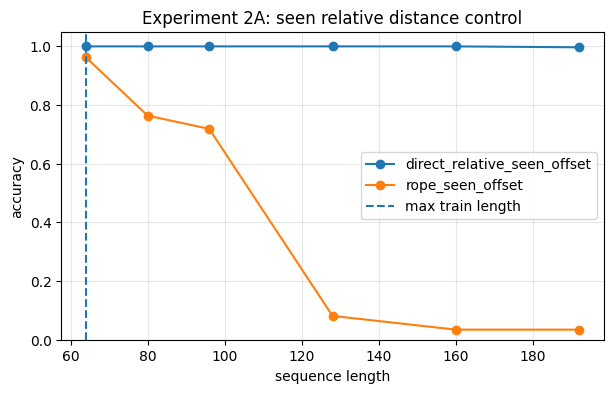

In [10]:
# ============================================================
# Experiment 2A
# Seen relative distance control
# ============================================================
#
# Here the required relative distance is always OFFSET.
# Since OFFSET is already seen during training, direct relative encoding
# should not fail merely because the test sequence is longer.

set_seed(SEED)

exp2a_models = {
    "direct_relative_seen_offset": RelativeOrRoPERetriever("direct_relative").to(DEVICE),
    "rope_seen_offset": RelativeOrRoPERetriever("rope").to(DEVICE),
}

exp2a_histories = []
exp2a_results = []

for name, model in exp2a_models.items():
    print("=" * 80)
    print("Experiment 2A training:", name)

    hist = train_exp2_model(
        model,
        batch_fn=lambda batch_size: make_fixed_offset_batch(
            batch_size,
            seq_len=TRAIN_LEN,
            offset=OFFSET,
        ),
        label=name,
    )

    result = evaluate_exp2_model(
        model,
        batch_fn=lambda batch_size, seq_len: make_fixed_offset_batch(
            batch_size,
            seq_len=seq_len,
            offset=OFFSET,
        ),
        lengths=TEST_LENGTHS,
        label=name,
    )

    exp2a_histories.append(hist)
    exp2a_results.append(result)

exp2a_history_df = pd.concat(exp2a_histories, ignore_index=True)
exp2a_result_df = pd.concat(exp2a_results, ignore_index=True)

display(exp2a_result_df)


plt.figure(figsize=(7, 4))

for model_name, group in exp2a_result_df.groupby("model"):
    group = group.sort_values("seq_len")
    plt.plot(
        group["seq_len"],
        group["accuracy"],
        marker="o",
        label=model_name,
    )

plt.axvline(TRAIN_LEN, linestyle="--", label="max train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Experiment 2A: seen relative distance control")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Experiment 2B training: direct_relative_unseen_distance
direct_relative_unseen_distance | step    1 | loss 3.5952 | train acc 0.031
direct_relative_unseen_distance | step  100 | loss 3.4153 | train acc 0.094
direct_relative_unseen_distance | step  200 | loss 3.3425 | train acc 0.078
direct_relative_unseen_distance | step  300 | loss 3.2108 | train acc 0.141
direct_relative_unseen_distance | step  400 | loss 1.8929 | train acc 0.734
direct_relative_unseen_distance | step  500 | loss 3.2131 | train acc 0.141
direct_relative_unseen_distance | step  600 | loss 1.7236 | train acc 0.641
Experiment 2B training: rope_unseen_distance
        rope_unseen_distance | step    1 | loss 3.5495 | train acc 0.047
        rope_unseen_distance | step  100 | loss 3.3886 | train acc 0.062
        rope_unseen_distance | step  200 | loss 2.7536 | train acc 0.203
        rope_unseen_distance | step  300 | loss 2.1170 | train acc 0.344
        rope_unseen_distance | step  400 | loss 1.3231 | train acc 0.578
  

,model,seq_len,is_extrapolation,accuracy,required_relative_distance
0,direct_relative_unseen_distance,64,False,0.020313,63
1,direct_relative_unseen_distance,80,True,0.043750,79
2,direct_relative_unseen_distance,96,True,0.045312,95
3,direct_relative_unseen_distance,128,True,0.023438,127
4,direct_relative_unseen_distance,160,True,0.037500,159
5,direct_relative_unseen_distance,192,True,0.029687,191
6,rope_unseen_distance,64,False,0.356250,63
7,rope_unseen_distance,80,True,0.037500,79
8,rope_unseen_distance,96,True,0.034375,95
9,rope_unseen_distance,128,True,0.043750,127


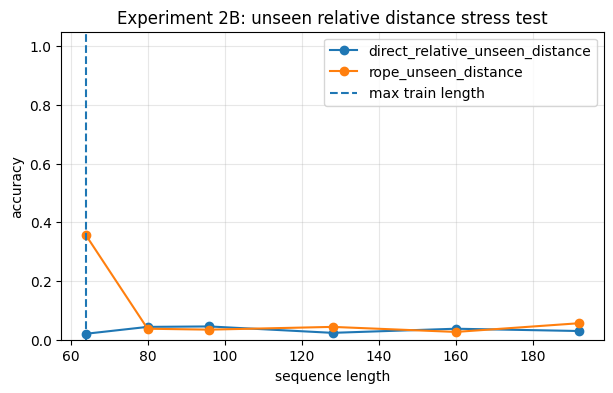

In [11]:
# ============================================================
# Experiment 2B
# Unseen relative distance stress test
# ============================================================
#
# Here the model is trained on first-token retrieval with variable
# sequence lengths up to TRAIN_LEN.
#
# During testing, longer sequences require relative distances larger
# than TRAIN_LEN - 1.
#
# For direct relative encoding, those table rows are not trained.

set_seed(SEED)

direct_unseen_model = RelativeOrRoPERetriever("direct_relative").to(DEVICE)
direct_unseen_rel_key_init = direct_unseen_model.rel_key.weight.detach().clone()

rope_unseen_model = RelativeOrRoPERetriever("rope").to(DEVICE)

exp2b_models = {
    "direct_relative_unseen_distance": direct_unseen_model,
    "rope_unseen_distance": rope_unseen_model,
}

exp2b_histories = []
exp2b_results = []

for name, model in exp2b_models.items():
    print("=" * 80)
    print("Experiment 2B training:", name)

    hist = train_exp2_model(
        model,
        batch_fn=make_variable_length_first_token_train_batch,
        label=name,
    )

    result = evaluate_exp2_model(
        model,
        batch_fn=make_first_token_batch_exp2,
        lengths=TEST_LENGTHS,
        label=name,
    )

    result["required_relative_distance"] = result["seq_len"] - 1

    exp2b_histories.append(hist)
    exp2b_results.append(result)

exp2b_history_df = pd.concat(exp2b_histories, ignore_index=True)
exp2b_result_df = pd.concat(exp2b_results, ignore_index=True)

display(exp2b_result_df)


plt.figure(figsize=(7, 4))

for model_name, group in exp2b_result_df.groupby("model"):
    group = group.sort_values("seq_len")
    plt.plot(
        group["seq_len"],
        group["accuracy"],
        marker="o",
        label=model_name,
    )

plt.axvline(TRAIN_LEN, linestyle="--", label="max train length")
plt.xlabel("sequence length")
plt.ylabel("accuracy")
plt.title("Experiment 2B: unseen relative distance stress test")
plt.ylim(0.0, 1.05)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

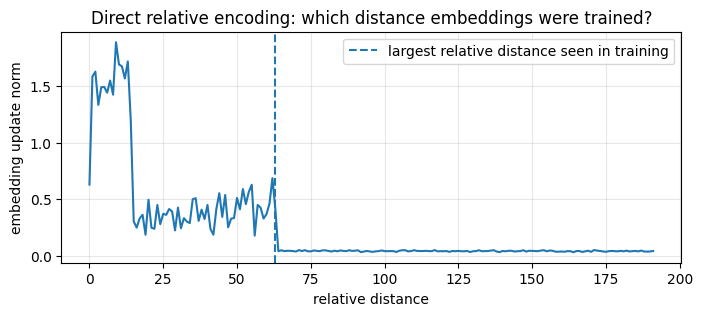

In [12]:
# ============================================================
# Diagnostic plot
# Which relative-distance embeddings were actually updated?
# ============================================================

with torch.no_grad():
    direct_unseen_rel_key_after = direct_unseen_model.rel_key.weight.detach().clone()

delta = torch.norm(
    direct_unseen_rel_key_after - direct_unseen_rel_key_init,
    dim=-1,
)

distances = torch.arange(0, MAX_TEST_LEN, device=DEVICE)
indices = distances + (MAX_TEST_LEN - 1)
distance_delta = delta[indices].detach().cpu().numpy()

plt.figure(figsize=(8, 3))
plt.plot(distances.detach().cpu().numpy(), distance_delta)

plt.axvline(
    TRAIN_LEN - 1,
    linestyle="--",
    label="largest relative distance seen in training",
)

plt.xlabel("relative distance")
plt.ylabel("embedding update norm")
plt.title("Direct relative encoding: which distance embeddings were trained?")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

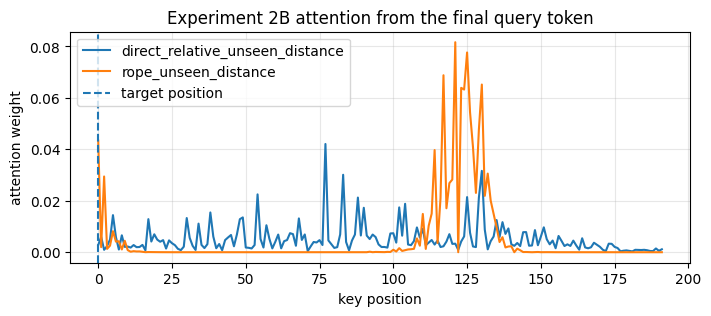

Target value: 7
 direct_relative_unseen_distance prediction: 11
            rope_unseen_distance prediction: 9


In [13]:
# ============================================================
# Attention visualization for Experiment 2B
# ============================================================

L = max(TEST_LENGTHS)
x, y = make_first_token_batch_exp2(batch_size=1, seq_len=L)

plt.figure(figsize=(8, 3))

for name, model in exp2b_models.items():
    model.eval()

    with torch.no_grad():
        logits, att = model(x, return_attn=True)

    plt.plot(
        att[0].detach().cpu().numpy(),
        label=name,
    )

plt.axvline(0, linestyle="--", label="target position")
plt.xlabel("key position")
plt.ylabel("attention weight")
plt.title("Experiment 2B attention from the final query token")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("Target value:", int(y.item()))

for name, model in exp2b_models.items():
    with torch.no_grad():
        pred = model(x).argmax(dim=-1).item()

    print(f"{name:>32s} prediction:", int(pred))

## 补充实验 2 结论

补充实验 2 的目的不是证明 RoPE 在所有长度外推任务上都一定成功，而是进一步区分 direct learned relative position encoding 和 RoPE 在“训练外相对距离”上的差异。

从 embedding update norm 的诊断图可以看到，direct relative encoding 在训练中出现过的相对距离范围内，位置向量发生了明显更新；而一旦超过训练中最大相对距离，更新幅度迅速接近 0。这说明 direct relative encoding 虽然可以为更长距离预先创建参数表项，但这些训练外距离对应的向量并没有被有效学习。

因此，direct relative encoding 的问题不在于它不能表达相对位置，而在于它把每一个相对距离都作为独立参数来学习：

$$
r_0, r_1, r_2, \cdots
$$

当测试时需要使用训练中没有出现过的相对距离时，对应的参数只是“存在”，但不是“学过”。这种表查找式结构本身缺乏自然的距离外推机制。

第二张注意力图也说明，这个 first-token retrieval 任务比固定 offset 检索更困难。目标位置是序列开头，也就是 key position 0。然而 direct relative encoding 的注意力分布比较分散，而 RoPE 的注意力峰值也没有稳定落在目标位置。这说明模型并没有真正学会“无论序列多长，都关注最左端 token”这一抽象边界规则。

因此，RoPE 的优势不能被过度解释为“自动完成所有长度外推任务”。更准确地说，RoPE 的优势在于：它不是为每个相对距离单独保存一个独立参数，而是通过连续的旋转结构生成相对位置关系。因此，当序列长度超过训练长度时，RoPE 的位置关系仍然在数学形式上具有结构化定义，不会像 direct relative table 那样遇到训练外表项几乎未更新的问题。

综上，补充实验 2 支持的结论是：direct learned relative position encoding 可以处理训练中见过的相对距离，但当测试需要训练外相对距离时，会暴露出查表式参数化的外推边界。RoPE 缓解的是位置表示本身的可延展性问题，但它并不保证模型一定学会所有需要长度泛化的任务规则。